In [ ]:

MODEL_PATH      = r"outputs/best_model.pth"
CSV_PATH        = r"final_neural_network_data.csv"
TREATMENTS_PATH = r"skin_disease_dataset2222/treatments.csv"


In [2]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
from torchvision import transforms, models
from torchvision.models import EfficientNet_B3_Weights

from IPython.display import display, HTML

IMG_SIZE = 300
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [3]:
# Model definition
class SkinDiseaseModel(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        backbone = models.efficientnet_b3(weights=None)
        for p in backbone.parameters():
            p.requires_grad = False
        self.features   = backbone.features
        self.pool       = backbone.avgpool
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(1536),
            nn.Dropout(p=dropout),
            nn.Linear(1536, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


# Load classes and treatments
df = pd.read_csv(CSV_PATH)
df.dropna(subset=['Disease', 'Image_Path'], inplace=True)
df['Disease'] = df['Disease'].str.strip().str.title()
classes       = sorted(df['Disease'].unique())
idx_to_class  = {i: c for i, c in enumerate(classes)}
NUM_CLASSES   = len(classes)

treatments_df = pd.read_csv(TREATMENTS_PATH, usecols=[0, 1, 7])
treatments_df.columns = ['Disease', 'Treatment', 'Avoid']
treatments_df['Disease'] = treatments_df['Disease'].str.strip().str.title()
treatments_df.dropna(subset=['Disease'], inplace=True)
TREATMENTS = dict(zip(
    treatments_df['Disease'],
    zip(treatments_df['Treatment'], treatments_df['Avoid'])
))

# Load model
model = SkinDiseaseModel(num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

print(f'Model loaded successfully!')
print(f'Number of disease classes: {NUM_CLASSES}')
print(f'Classes: {classes}')

Model loaded successfully!
Number of disease classes: 8
Classes: ['Acne', 'Contact Dermatitis', 'Eczema', 'Impetigo', 'Psoriasis', 'Skin Cancer', 'Vitiligo', 'Warts']


In [6]:
# Prediction function
def predict(image_path):
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    img    = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)[0]

    top3_conf, top3_idx = torch.topk(probs, k=min(3, NUM_CLASSES))
    top_disease    = idx_to_class[top3_idx[0].item()]
    top_confidence = top3_conf[0].item()
    treatment, avoid = TREATMENTS.get(top_disease, ('No data available', 'No data available'))

    return {
        'disease':    top_disease,
        'confidence': top_confidence,
        'treatment':  str(treatment),
        'avoid':      str(avoid),
        'top3': [(idx_to_class[top3_idx[i].item()], top3_conf[i].item()) for i in range(len(top3_idx))],
        'image':      img,
        'probs':      probs.cpu().numpy()
    }


def show_result(result, image_path):
    fig = plt.figure(figsize=(16, 7))
    fig.patch.set_facecolor('#0f1117')

    # ── Left: image ──
    ax_img = fig.add_axes([0.02, 0.05, 0.32, 0.90])
    ax_img.imshow(result['image'])
    ax_img.axis('off')
    ax_img.set_title(os.path.basename(image_path), color='white', fontsize=10, pad=8)

    # ── Middle: info panel ──
    ax_info = fig.add_axes([0.36, 0.05, 0.35, 0.90])
    ax_info.set_facecolor('#1a1d27')
    ax_info.set_xlim(0, 1)
    ax_info.set_ylim(0, 1)
    ax_info.axis('off')

    conf_pct = result['confidence'] * 100
    conf_color = '#00e676' if conf_pct >= 70 else '#ffab40' if conf_pct >= 50 else '#ef5350'

    ax_info.text(0.5, 0.95, 'DIAGNOSIS', ha='center', va='top',
                 color='#90caf9', fontsize=11, fontweight='bold', fontfamily='monospace')
    ax_info.text(0.5, 0.85, result['disease'], ha='center', va='top',
                 color='white', fontsize=16, fontweight='bold')
    ax_info.text(0.5, 0.75, f"Confidence: {conf_pct:.1f}%", ha='center', va='top',
                 color=conf_color, fontsize=13, fontweight='bold')

    ax_info.axhline(0.70, color='#333', linewidth=1)

    ax_info.text(0.05, 0.65, 'TREATMENT:', ha='left', va='top',
                 color='#80cbc4', fontsize=10, fontweight='bold')
    _draw_wrapped(ax_info, 0.05, 0.58, result['treatment'], color='#e0e0e0', max_w=52)

    ax_info.axhline(0.35, color='#333', linewidth=1)

    ax_info.text(0.05, 0.30, 'AVOID:', ha='left', va='top',
                 color='#ef9a9a', fontsize=10, fontweight='bold')
    _draw_wrapped(ax_info, 0.05, 0.23, result['avoid'], color='#e0e0e0', max_w=52)

    ax_info.text(0.5, 0.01,
                 'For educational purposes only. Consult a dermatologist.',
                 ha='center', va='bottom', color='#555', fontsize=7, style='italic')

    # ── Right: top-3 bar chart ──
    ax_bar = fig.add_axes([0.74, 0.15, 0.24, 0.70])
    ax_bar.set_facecolor('#1a1d27')

    names  = [r['disease'] for r in [{'disease': d, 'conf': c} for d, c in result['top3']]]
    confs  = [c for _, c in result['top3']]
    names2 = [d for d, _ in result['top3']]
    colors = ['#00e676', '#42a5f5', '#ab47bc']

    bars = ax_bar.barh(range(len(confs)), [c*100 for c in confs],
                       color=colors[:len(confs)], height=0.5, edgecolor='none')
    ax_bar.set_xlim(0, 100)
    ax_bar.set_yticks(range(len(confs)))
    ax_bar.set_yticklabels([f'{i+1}. {d}' for i, d in enumerate(names2)],
                           color='white', fontsize=9)
    ax_bar.set_xlabel('Confidence %', color='#aaa', fontsize=9)
    ax_bar.tick_params(colors='#aaa')
    ax_bar.spines[:].set_color('#333')
    ax_bar.set_title('Top Predictions', color='#90caf9', fontsize=10, fontweight='bold')
    for bar, c in zip(bars, confs):
        ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{c*100:.1f}%', va='center', color='white', fontsize=9)

    plt.suptitle('Skin Disease Analysis Report', color='white',
                 fontsize=15, fontweight='bold', y=0.98)
    plt.show()


def _draw_wrapped(ax, x, y, text, color, max_w=50, line_h=0.07):
    words, line, lines = text.split(), '', []
    for w in words:
        if len(line) + len(w) + 1 <= max_w:
            line = (line + ' ' + w).strip()
        else:
            lines.append(line); line = w
    if line: lines.append(line)
    for i, l in enumerate(lines[:4]):
        ax.text(x, y - i*line_h, l, ha='left', va='top', color=color, fontsize=8.5)

print('Functions ready!')

Functions ready!


## Run Prediction
Change the path below and run the cell

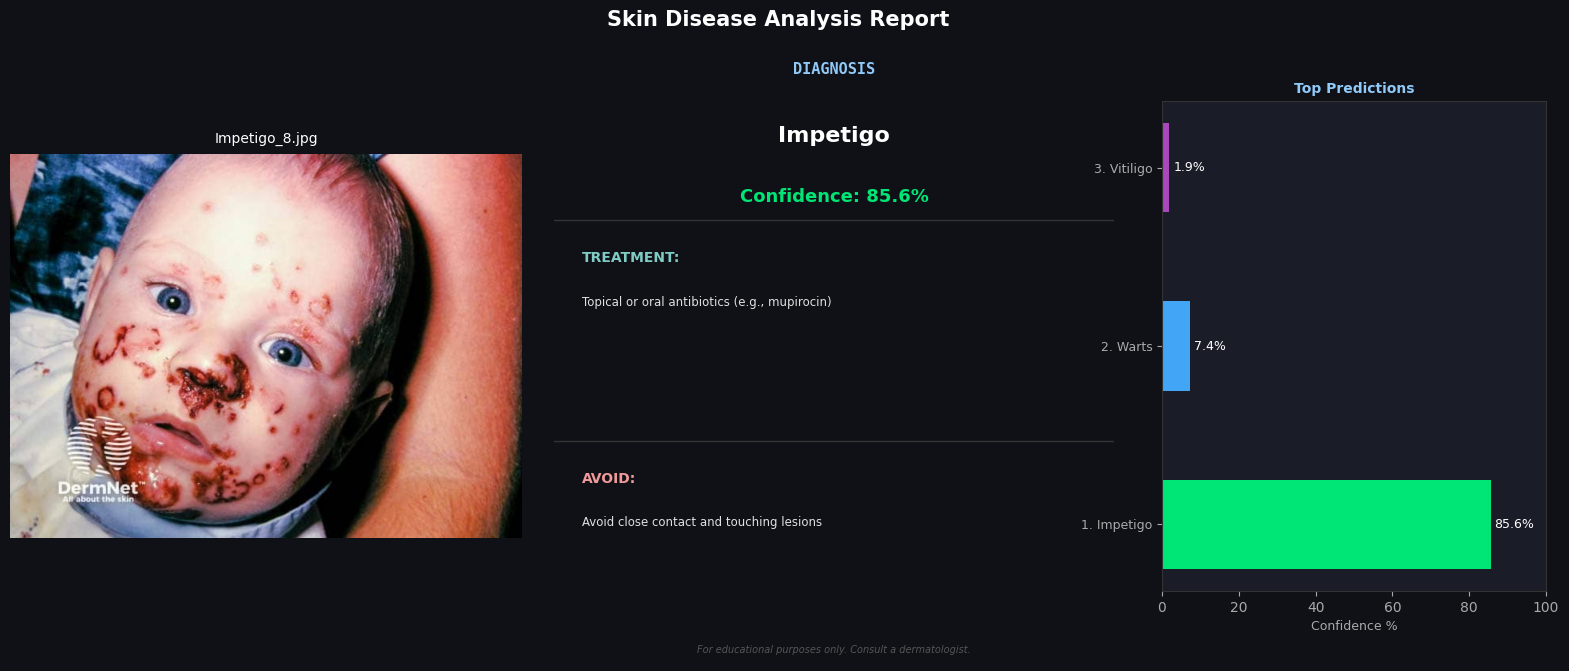

Disease   : Impetigo
Confidence: 85.6%
Treatment : Topical or oral antibiotics (e.g., mupirocin)
Avoid     : Avoid close contact and touching lesions


In [9]:

IMAGE_PATH = r"C:\Users\sandy\Downloads\Neural-Project-main\Neural-Project-main\dermnet_dataset\Impetigo\Impetigo_8.jpg"

if not os.path.exists(IMAGE_PATH):
    print(f'ERROR: Image not found -> {IMAGE_PATH}')
else:
    result = predict(IMAGE_PATH)
    show_result(result, IMAGE_PATH)
    print(f'Disease   : {result["disease"]}')
    print(f'Confidence: {result["confidence"]*100:.1f}%')
    print(f'Treatment : {result["treatment"]}')
    print(f'Avoid     : {result["avoid"]}')